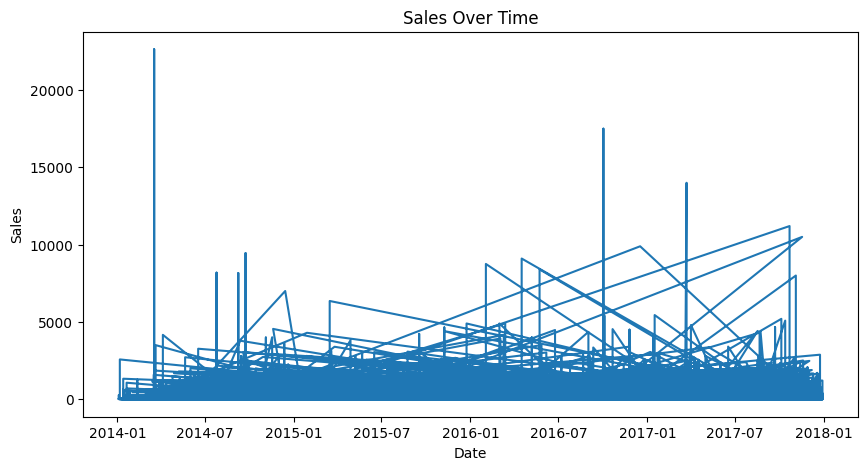

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/datas.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.head()
df.isnull().sum()
df.describe()
df['Sales'] = df['Sales'].ffill()
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day'] = df['Order Date'].dt.day
df['day_of_week'] = df['Order Date'].dt.dayofweek
plt.figure(figsize=(10,5))
plt.plot(df['Order Date'], df['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X = df[['year','month','day','day_of_week']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 270.74889603474213
RMSE: 618.8633990872007


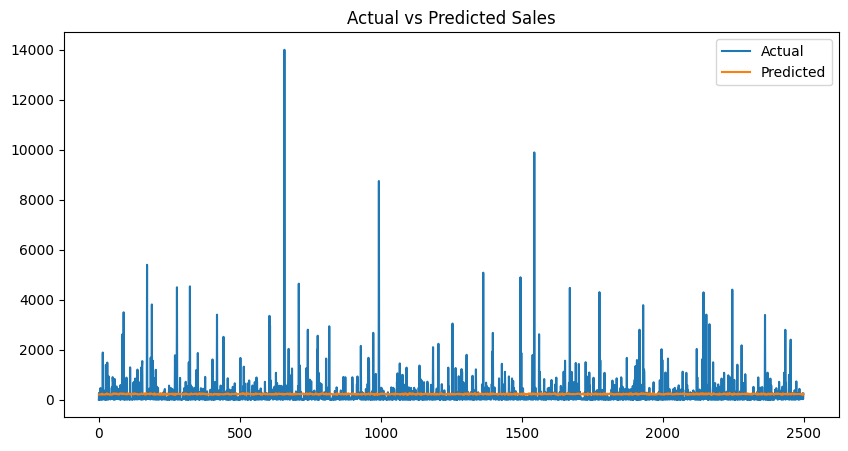

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()


In [ ]:
future_dates = pd.date_range(start=df['Order Date'].max(), periods=30)

future_df = pd.DataFrame({'Order Date': future_dates})
future_df['year'] = future_df['Order Date'].dt.year
future_df['month'] = future_df['Order Date'].dt.month
future_df['day'] = future_df['Order Date'].dt.day
future_df['day_of_week'] = future_df['Order Date'].dt.dayofweek

future_sales = model.predict(future_df[['year','month','day','day_of_week']])
future_df['forecast_sales'] = future_sales


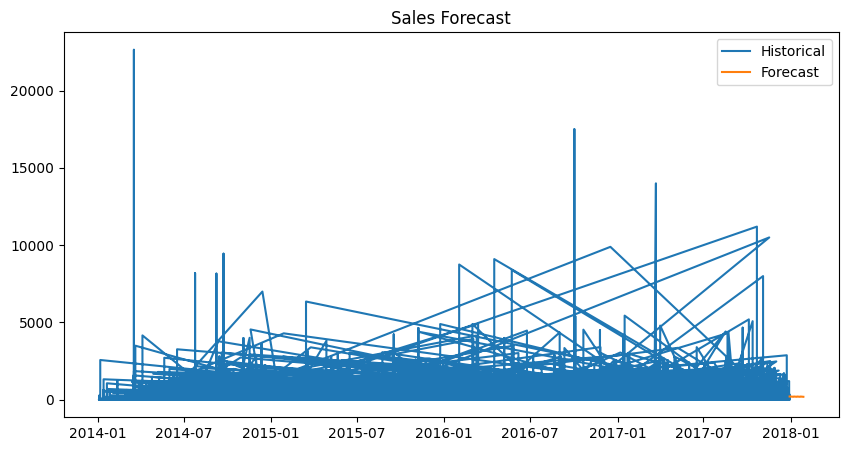

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df['Order Date'], df['Sales'], label='Historical')
plt.plot(future_df['Order Date'], future_df['forecast_sales'], label='Forecast')
plt.legend()
plt.title("Sales Forecast")
plt.show()
